In [1]:
import os
import csv
import datetime as dt
import pandas as pd
import numpy as np

# index를 날짜로 하는 데이터프레임을 price, adj_price, divend에 대해 반환
def extract_stock_data(file_path, ticker):
    extract_datas = []

    with open(os.path.join(file_path, ticker + '.csv'), newline='') as csvfile:
        reader = csv.reader(csvfile)

        for row in reader:
            extract_datas.append(row)
        
    price_dates = list(map(dt.date.fromisoformat, extract_datas[0]))
    price_history = list(map(float, extract_datas[1]))
    adj_price_dates = list(map(dt.date.fromisoformat, extract_datas[2]))
    adj_price_history = list(map(float, extract_datas[3]))
    divend_dates = list(map(dt.date.fromisoformat, extract_datas[4]))
    divend_history = list(map(float, extract_datas[5]))

    price_df = pd.DataFrame({'date': price_dates, 'price': price_history})
    adj_price_df = pd.DataFrame({'date': adj_price_dates, 'adj_price': adj_price_history})
    divend_df = pd.DataFrame({'date': divend_dates, 'divend': divend_history})

    price_df.set_index('date', inplace=True)
    adj_price_df.set_index('date', inplace=True)
    divend_df.set_index('date', inplace=True)

    return (price_df, adj_price_df, divend_df)

def make_stock_data(file_path, tickers):
    stock_data = []

    for ticker in tickers:
        price_df, adj_price_df, divend_df = extract_stock_data(file_path, ticker)
        stock_df = pd.concat([price_df, adj_price_df, divend_df], axis=1, sort=True)
        stock_df.columns = pd.MultiIndex.from_product([[ticker], stock_df.columns])
        stock_data.append(stock_df)

    stock_data = pd.concat(stock_data, axis=1, sort=True)

    return stock_data


In [156]:
import itertools

class Portfolio:
    # stock_data
    def __init__(self, stock_data: pd.DataFrame, start_cash: float, target_ratio: dict = None, buy_ratio: float = 5.0, sell_ratio: float = 5.0):
        self.__stock_list = set(stock_data.columns.get_level_values(0))
        if target_ratio is None:
            target_ratio = {ticker: round(100 / len(self.__stock_list), 2) for ticker in self.__stock_list}
        self.__stock_list = list(self.__stock_list.intersection(target_ratio.keys()))
        target_ratio_list = list(target_ratio)
        self.__stock_list.sort(key=lambda x: target_ratio_list.index(x))
        stock_data = stock_data.loc[:, self.__stock_list]
        self.__price_data = stock_data.loc[:, (stock_data.columns.get_level_values(1) == 'price')].copy()
        self.__price_data = self.__price_data.droplevel(1, axis=1)
        self.__adj_price_data = stock_data.loc[:, (stock_data.columns.get_level_values(1) == 'adj_price')].copy()
        self.__adj_price_data = self.__adj_price_data.droplevel(1, axis=1)
        self.__divend_data = stock_data.loc[:, (stock_data.columns.get_level_values(1) == 'divend')].copy()
        self.__divend_data = self.__divend_data.droplevel(1, axis=1)
        self.__start_cash = start_cash
        # target_ratio의 구성 { stock명 : 목표 비중, ... }
        self.target_ratio = target_ratio
        self.buy_ratio = buy_ratio
        self.sell_ratio = sell_ratio
        self.__target_buy_ratio = {ticker: target_ratio[ticker] * buy_ratio / 100 for ticker in self.stock_list}
        self.__target_sell_ratio = {ticker: target_ratio[ticker] * sell_ratio / 100 for ticker in self.stock_list}
    

        self.__price_data.dropna(inplace=True)
        self.__avilable_date = self.price_data.iloc[0].name
        self.__adj_price_data = self.__adj_price_data[self.__adj_price_data.index >= self.__avilable_date]
        self.__divend_data = self.__divend_data[self.__divend_data.index >= self.__avilable_date]
        
    @property
    def stock_list(self) -> list:
        return self.__stock_list
    @property
    def price_data(self) -> pd.DataFrame:
        return self.__price_data
    @property
    def adj_price_data(self) -> pd.DataFrame:
        return self.__adj_price_data
    @property
    def divend_data(self) -> pd.DataFrame:
        return self.__divend_data
    @property
    def start_date(self) -> dt.date:
        return self.__avilable_date

    def backtest(self, start_date=None, duration=None, rebalancing_cycle=None, benchmark=None):
        info_list =  ['price', 'number', 'value', 'weight']
        stock_info =  list(itertools.product(self.stock_list, info_list))

        col = [('total', 'value'), ('cash', 'value'), ('cash', 'weight')] + stock_info
        col = pd.MultiIndex.from_tuples(col)

        dates = self.__available_dates(start_date, duration)
        rebalancing_dates = dates[::rebalancing_cycle] if rebalancing_cycle else dates
        stat = pd.DataFrame(columns=col, index=dates)

        # 첫 값 설정
        first_date = dates[0]
        total_value = self.__start_cash
        for ticker in self.stock_list:
            stat.loc[first_date, ('total', 'value')] = total_value
            stat.loc[first_date, ('cash', 'value')] = 0
            stat.loc[first_date, ('cash', 'weight')] = 0
            stat.loc[:, (ticker, 'price')] = self.price_data[ticker]
            stat.loc[first_date, (stat.columns.get_level_values(0) == ticker) & (stat.columns.get_level_values(1) != 'price')] = self.__ideal_nvw(total_value, ticker, first_date)
            
        for i in range(1, len(dates)):
            cash_value = stat.loc[dates[i - 1]][('cash', 'value')]
            total_value = cash_value
            # 가격 변동 처리
            prev_num = stat.loc[dates[i - 1]][:, 'number']
            prev_num_pv = prev_num * self.price_data.loc[dates[i]]
            total_value += prev_num_pv.sum()
            # 배당금 처리
            divend_df = self.acculate_divend(dates[i-1], dates[i])
            divend = (divend_df.sum() * prev_num).sum()
            cash_value += divend
            total_value += divend
            stat.loc[dates[i], ('cash', 'value')] = cash_value
            stat.loc[dates[i], ('total', 'value')] = total_value

            # 변동에 따른 리밸런싱 계산
            prev_num_ratio = prev_num_pv / total_value * 100
            target_ratio_sr = pd.Series(self.target_ratio)
            ratio_diff = (prev_num_ratio - target_ratio_sr)

            need_sell = ratio_diff[ratio_diff >= pd.Series(self.__target_sell_ratio)].index.to_list()
            need_buy = ratio_diff[ratio_diff <= -pd.Series(self.__target_buy_ratio)].index.to_list()
            need_trade = need_sell + need_buy
            for ticker in self.stock_list:
                if dates[i] in rebalancing_dates and ticker in need_trade:
                    stat.loc[dates[i], (stat.columns.get_level_values(0) == ticker) & (stat.columns.get_level_values(1) != 'price')] = self.__ideal_nvw(total_value, ticker, dates[i])
                    stat.loc[dates[i], ('cash', 'value')] += ratio_diff[ticker] * total_value * 0.01
                else:
                    stat.loc[dates[i], (ticker, 'number')] = stat.loc[dates[i - 1], (ticker, 'number')]
                    stat.loc[dates[i], (ticker, 'value')] = prev_num_pv[ticker]
                    stat.loc[dates[i], (ticker, 'weight')] = prev_num_ratio[ticker]
            
            stat.loc[dates[i], ('cash', 'weight')] = stat.loc[dates[i]][('cash', 'value')] / total_value * 100

        stat.insert(0, ('rebalancing', 'flag'), False)
        stat.loc[rebalancing_dates, ('rebalancing', 'flag')] = True

        res_df = pd.DataFrame(columns=['portfolio'], index=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])
        start_price = stat.loc[dates[0], ('total', 'value')]
        end_price = stat.loc[dates[-1], ('total', 'value')]
        res_df.loc['cagr', 'portfolio'] = ((end_price / start_price) ** (252 / len(dates)) - 1) * 100
        res_df.loc['stdev', 'portfolio'] = stat.loc[:, ('total', 'value')].pct_change().std() * np.sqrt(252) * 100
        peak_value = stat[('total', 'value')].cummax()
        drawdown = (stat[('total', 'value')] - peak_value) / peak_value
        res_df.loc['mdd', 'portfolio'] = -1 * drawdown.min() * 100
        if benchmark is not None:
            alpha, beta = Portfolio.alphabeta(benchmark, stat.loc[:, ('total', 'value')], duration=duration)
            res_df.loc['alpha', 'portfolio'] = alpha
            res_df.loc['beta', 'portfolio'] = beta

        return stat, res_df

    # 범위는 (start_date, end_date]
    def acculate_divend(self, start_date, end_date):
        divend_df = self.divend_data[(self.divend_data.index > start_date) & (self.divend_data.index <= end_date)]
        return divend_df
    
    def stock_stdev(self, tickers=[], start_date=None, duration=None):
        if not tickers:
            tickers = self.stock_list

        data_df = self.adj_price_data.loc[self.__available_dates(start_date, duration), tickers]

        std_df = pd.DataFrame(columns=tickers, index=['stdev'])
        for ticker in tickers:
            std_df.loc['stdev', ticker] = data_df[ticker].pct_change().std() * np.sqrt(252)

        return std_df * 100

    def stock_cagr(self, tickers=[], start_date=None, duration=None):
        if not tickers:
            tickers = self.stock_list

        data_df = self.adj_price_data.loc[self.__available_dates(start_date, duration), tickers]
        
        cagr_df = pd.DataFrame(columns=tickers, index=['cagr'])
        for ticker in tickers:
            start_price = data_df[ticker].iloc[0]
            end_price = data_df[ticker].iloc[-1]
            cagr_df.loc['cagr', ticker] = (end_price / start_price) ** (252 / len(data_df.index)) - 1

        return cagr_df * 100
    
    def stock_mdd(self, tickers=[], start_date=None, duration=None):
        if not tickers:
            tickers = self.stock_list

        data_df = self.adj_price_data.loc[self.__available_dates(start_date, duration), tickers]
        
        mdd_df = pd.DataFrame(columns=tickers, index=['mdd'])
        for ticker in tickers:
            price_sr = data_df[ticker]
            peak_price = price_sr.cummax()
            drawdown = (price_sr - peak_price) / peak_price
            mdd_df.loc['mdd', ticker] = drawdown.min()

        return -1 * (mdd_df * 100)
    
    def stock_corr(self, tickers=[], start_date=None, duration=None):
        if not tickers:
            tickers = self.stock_list

        data_df = self.adj_price_data.loc[self.__available_dates(start_date, duration), tickers]
        ret_df = data_df.pct_change()
        corr_df = ret_df.corr()

        return corr_df

    def stock_alphabeta(self, market_value, tickers=[], start_date=None, duration=None, risk_free_rate=0.02):
        if not tickers:
            tickers = self.stock_list

        market_value = market_value.loc[self.__available_dates(start_date, duration)]

        alphabeta_df = pd.DataFrame(columns=tickers, index=['alpha', 'beta'])
        for ticker in tickers:
            target_value = self.adj_price_data.loc[self.__available_dates(start_date, duration), ticker]
            alpha, beta = Portfolio.alphabeta(market_value, target_value)
            alphabeta_df.loc['alpha', ticker] = alpha
            alphabeta_df.loc['beta', ticker] = beta

        return alphabeta_df
    
    def __ideal_nvw(self, total_value, ticker, date):
        target_ratio = self.target_ratio[ticker] * 0.01
        value = round(total_value * target_ratio, 3)
        price = self.price_data.loc[date][ticker]
        number = round(value / price, 6)
        return (number, value, target_ratio * 100)
    
    def __available_dates(self, start_date = None, duration=None) -> pd.Index:
        if not start_date or start_date < self.start_date:
            start_date = self.start_date

        if start_date > self.price_data.index[-1]:
            start_date = self.price_data.index[-1]

        for date in self.price_data.index:
            if date >= start_date:
                start_date = date
                break

        start_idx = self.price_data.index.get_loc(start_date)
        
        date_len = len(self.price_data.index) - start_idx
        if duration:
            date_len = min(date_len, 252 * duration)
        end_idx = start_idx + date_len
        
        return self.price_data.index[start_idx:end_idx]
    
    @staticmethod
    def alphabeta(market_value, target_value, risk_free_rate=0.02, duration=None):
        market_value = market_value.dropna()
        target_value = target_value.dropna()

        start_date = max(market_value.index[0], target_value.index[0])
        end_date = min(market_value.index[-1], target_value.index[-1])
        if duration:
            end_date = min(end_date, start_date + pd.Timedelta(days=duration * 365))
            
        market_value = market_value[(market_value.index >= start_date) & (market_value.index < end_date)]
        target_value = target_value[(target_value.index >= start_date) & (target_value.index < end_date)]

        market_ret = np.array(market_value.pct_change().dropna(), dtype=np.float64)
        target_ret = np.array(target_value.pct_change().dropna(), dtype=np.float64)
        
        cov = np.cov(market_ret, target_ret)[0][1]
        var = np.var(market_ret)
        beta = cov / var
        expected_ret = risk_free_rate + beta * (market_ret.mean() * 252 - risk_free_rate)
        alpha = (target_ret.mean() * 252 - expected_ret) * 100

        return alpha, beta

In [157]:
# stock 불러와서 데이터프레임화 하기
file_path = './etf'
tickers = ['QQQ', 'DGRW', 'SCHD', 'SPY', 'SCHG', 'SPYG']
stock_data = make_stock_data(file_path, tickers)
pd.options.display.float_format = '{:.2f}'.format

# test_stock = Portfolio(make_stock_data(file_path, ['QQQ', 'SCHG']), 10000)
test_stock = Portfolio(stock_data, 10000)
portfolio = Portfolio(stock_data, 10000, {"QQQ":56, "SCHD":24, "DGRW":20})

In [158]:
alpha_beta = test_stock.stock_alphabeta(stock_data[('QQQ', 'adj_price')], risk_free_rate=0.02)
pd.concat([test_stock.stock_cagr(), test_stock.stock_stdev(), test_stock.stock_mdd(), alpha_beta], axis=0)

,SCHD,SPYG,SCHG,SPY,QQQ,DGRW
cagr,12.14,16.58,17.08,14.22,20.17,13.13
stdev,15.81,19.28,20.07,16.99,20.97,15.52
mdd,33.33,32.67,34.59,33.72,35.12,32.04
alpha,0.51,-1.41,-1.57,-1.31,-0.01,-0.36
beta,0.54,0.90,0.93,0.76,1.00,0.64


In [159]:
test_stock.stock_corr()

,SCHD,SPYG,SCHG,SPY,QQQ,DGRW
SCHD,1.00,0.76,0.74,0.88,0.72,0.93
SPYG,0.76,1.00,0.99,0.97,0.97,0.90
SCHG,0.74,0.99,1.00,0.96,0.98,0.89
SPY,0.88,0.97,0.96,1.00,0.93,0.97
QQQ,0.72,0.97,0.98,0.93,1.00,0.87
DGRW,0.93,0.90,0.89,0.97,0.87,1.00


In [162]:
portfolio.backtest(rebalancing_cycle=5, benchmark=stock_data[('QQQ', 'adj_price')])

(           rebalancing    total    cash           QQQ                         \
                   flag    value   value weight  price number    value weight   
 date                                                                           
 2013-05-22        True    10000       0      0  73.62  76.07  5600.00  56.00   
 2013-05-23       False  9974.26    0.00   0.00  73.45  76.07  5587.07  56.01   
 2013-05-24       False  9975.47    0.00   0.00  73.41  76.07  5584.03  55.98   
 2013-05-28       False 10043.75    0.00   0.00  73.89  76.07  5620.54  55.96   
 2013-05-29       False  9972.07    0.00   0.00  73.54  76.07  5593.91  56.10   
 ...                ...      ...     ...    ...    ...    ...      ...    ...   
 2026-05-18       False 75103.65 -913.23  -1.22 705.88  61.61 43485.88  57.90   
 2026-05-19       False 74794.39 -913.23  -1.22 701.53  61.61 43217.89  57.78   
 2026-05-20       False 75611.19 -913.23  -1.21 713.15  61.61 43933.75  58.10   
 2026-05-21       False 7578

In [194]:
def portfolio_backtest_by_duration(portfolio:Portfolio, benchmark=None, duration=1, start_date=None):
    if not start_date:
        start_date = portfolio.start_date
    start_date_limit = dt.date.today() - dt.timedelta(days=365 * duration)

    stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])
    date = start_date
    while date <= start_date_limit:
        _, stat = portfolio.backtest(start_date=date, duration=duration, rebalancing_cycle=5, benchmark=benchmark)
        stats = pd.concat([stats, stat.T])
        date = date + dt.timedelta(days=365)
    
    stats.reset_index(inplace=True)
    stats.rename(columns={'index': 'ratio'}, inplace=True)

    ratio_str = ""
    for ticker, weight in portfolio.target_ratio.items():
        ratio_str += f"{weight:.1f}:"
    ratio_str = ratio_str.rstrip(':')
    stats.loc[:, 'ratio'] = ratio_str

    return stats

In [195]:
def calc_target_ratio(base_ratio:tuple, etc_ratio:tuple) -> tuple:
    base_sum = sum(base_ratio)
    qqq = base_ratio[0] / base_sum * 100
    etc_sum = sum(etc_ratio)
    etc1 = (etc_ratio[0] / etc_sum) * (base_ratio[1] / base_sum) * 100
    etc2 = (etc_ratio[1] / etc_sum) * (base_ratio[1] / base_sum) * 100

    return (round(qqq, 1), round(etc1, 1), round(etc2, 1))

In [196]:
stats = pd.DataFrame(columns=['cagr', 'stdev', 'mdd', 'beta', 'alpha'])

for qqq_weight in range(5, 10):
    for schd_weight in range(1, 10):
        ratio_qqq_etc = (qqq_weight, 10-qqq_weight)
        ratio_schd_dgrw = (schd_weight, 10-schd_weight)
        ratio_qqq_schd_dgrw = calc_target_ratio(ratio_qqq_etc, ratio_schd_dgrw)
        print('loading:' + str(ratio_qqq_schd_dgrw))
        
        target_ratio = {
            'QQQ': ratio_qqq_schd_dgrw[0],
            'SCHD': ratio_qqq_schd_dgrw[1],
            'DGRW': ratio_qqq_schd_dgrw[2]
        }

        portfolio = Portfolio(stock_data, 10000, target_ratio)
        stat = portfolio_backtest_by_duration(portfolio, benchmark=stock_data[('QQQ', 'adj_price')], duration=5)
        stats = pd.concat([stats, stat])
    
    break

stats

loading:(50.0, 5.0, 45.0)
loading:(50.0, 10.0, 40.0)
loading:(50.0, 15.0, 35.0)
loading:(50.0, 20.0, 30.0)
loading:(50.0, 25.0, 25.0)
loading:(50.0, 30.0, 20.0)
loading:(50.0, 35.0, 15.0)
loading:(50.0, 40.0, 10.0)
loading:(50.0, 45.0, 5.0)


,cagr,stdev,mdd,beta,alpha,ratio
0,15.91,13.22,13.52,0.85,-0.67,50.0:5.0:45.0
1,13.09,14.35,20.39,0.83,-0.53,50.0:5.0:45.0
2,12.26,19.46,30.38,0.89,-2.62,50.0:5.0:45.0
3,21.84,19.51,29.89,0.86,-0.92,50.0:5.0:45.0
4,14.93,20.61,29.51,0.83,0.51,50.0:5.0:45.0
...,...,...,...,...,...,...
4,15.55,20.35,30.23,0.80,1.45,50.0:45.0:5.0
5,13.57,21.61,30.21,0.79,0.41,50.0:45.0:5.0
6,17.21,21.10,30.18,0.79,0.18,50.0:45.0:5.0
7,15.63,17.85,25.19,0.71,2.10,50.0:45.0:5.0


In [ ]:
stat = portfolio_backtest_by_duration(portfolio, duration=5, benchmark=stock_data[('QQQ', 'adj_price')])

KeyboardInterrupt: 

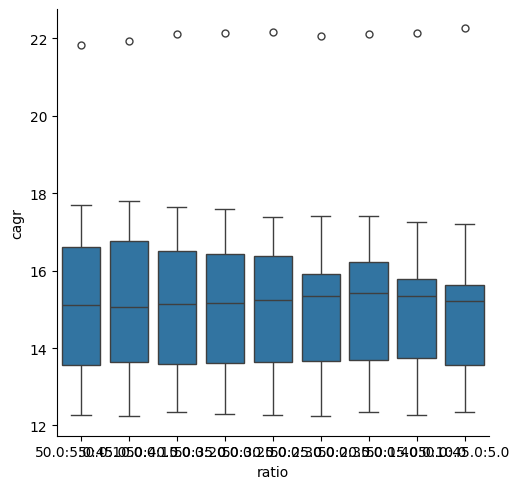

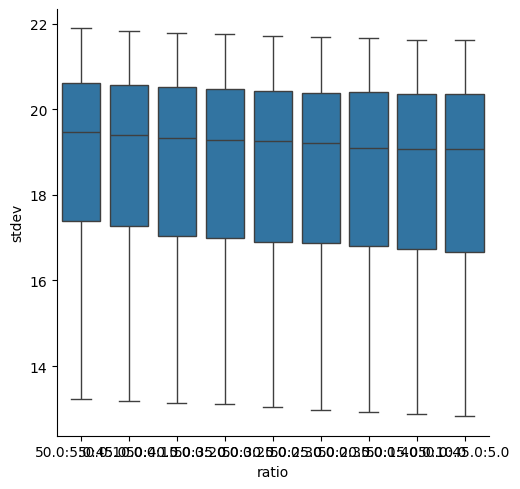

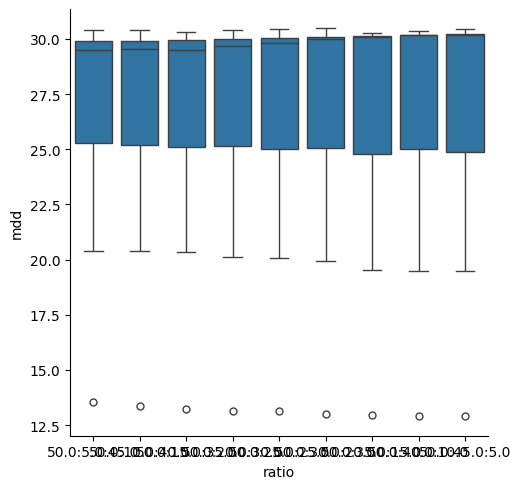

In [198]:
import seaborn as sns

sns.catplot(data=stats, x='ratio', y='cagr', kind='box')
sns.catplot(data=stats, x='ratio', y='stdev', kind='box')
sns.catplot(data=stats, x='ratio', y='mdd', kind='box')

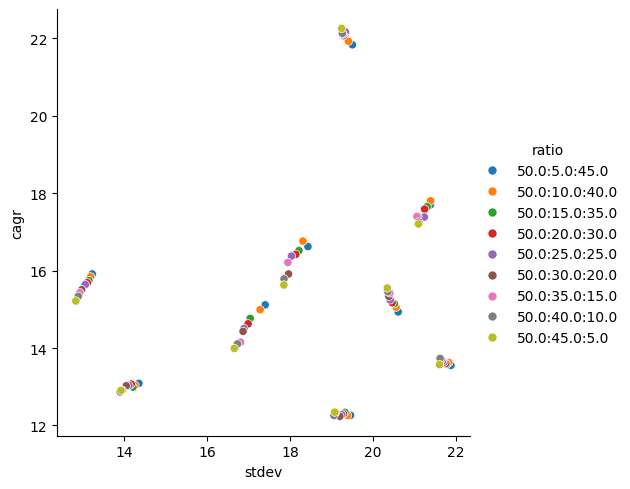

In [199]:
sns.relplot(data=stats, x='stdev', y='cagr', hue='ratio')